# 03 · Blending: combining models, and choosing the combination honestly

Every model in the ledger produced **out-of-fold (OOF)** predictions on the same
five cross-validation folds, so each training row has one leakage-free prediction
per model. That makes it possible to learn how to combine the models without
touching the test set. This notebook:

1. loads the level-1 base models' OOF vectors (with the row-alignment guard);
2. measures how different the models really are, and curates a pool of one model
   per engine;
3. compares combiners — weighted means, rank averaging, Caruana hill climbing, and
   stacking with logistic-regression and LightGBM meta-learners; and
4. shows what held-out data said about the six combiners that were **fixed before
   any leaderboard score was seen**, including a direct case of selection bias: the
   combiner with the best OOF score was not the best on the private leaderboard.

The machinery lives in [src/blending.py](src/blending.py), shared with
`scripts/run_blend_logging.py`, which logged the six headline blends to the ledger
and submitted them.

*Prerequisites: the OOF/test prediction arrays under `experiments/runs/` (produced
by the experiments; not committed to the repository because of their size).*

## 1. Load the aligned OOF matrix

`load_aligned_runs` reads every run's `oof_proba.npy` and `test_proba_mean.npy`,
re-computes each OOF ROC-AUC and asserts it equals the ledger value to 1e-9 —
proof that the rows line up — and drops runs trained on a subsample. Previously
logged blends are always excluded (a blend is never a member of a blend); the
level-2 stacking runs are excluded too, so every column here is a level-1 model.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score

from src import blending as bl
from src.tracking import RUNS_DIR, load_runs

plt.rcParams['figure.dpi'] = 80

y, folds = bl.load_target_and_folds()
oof, test, meta, spearman = bl.load_aligned_runs(
    y, exclude_versions=('blend_v1', 'fe_v5_stack', 'fe_v6_perfold'))
print(f'OOF matrix: {oof.shape[0]:,} rows x {oof.shape[1]} level-1 runs '
      f'(churn rate {y.mean():.4f})')
print(meta['engine'].value_counts().to_string())

Loaded from cache (native): train_df (594194, 21), test_df (254655, 20)


OOF matrix: 594,194 rows x 44 level-1 runs (churn rate 0.2252)
engine
LightGBM        15
XGBoost          7
CatBoost         6
EBM              3
Logistic         3
RandomForest     2
RealMLP          2
TabM             2
ExtraTrees       2
TabPFN           1
TabICL           1


## 2. How different are the models?

A blend helps only when its members are individually strong **and** make different
mistakes. Because ROC-AUC depends only on how the predictions *rank* customers, the
relevant similarity measure is the **Spearman** (rank) correlation between two
models' OOF predictions: ρ = 1 means they rank every customer in the same order.

In [2]:
pairs = spearman.where(np.triu(np.ones(spearman.shape, dtype=bool), k=1)).stack()
eng = meta.set_index('label')['engine']
same_engine = [eng[a] == eng[b] for a, b in pairs.index]
summary = pd.DataFrame({'rho': pairs.values, 'same_engine': same_engine})
print(summary.groupby('same_engine')['rho'].describe()[['count', 'min', '50%', 'max']]
      .rename(index={True: 'same engine', False: 'different engines'})
      .to_string(float_format='{:.4f}'.format))

                     count    min    50%    max
same_engine                                    
different engines 795.0000 0.9610 0.9911 0.9990
same engine       151.0000 0.9851 0.9962 1.0000


Every pair of models ranks customers almost identically: the median Spearman
correlation is 0.991 between *different* engines and 0.996 between re-tunings of the
*same* engine, and the least-correlated pair still reaches 0.961. The 44 runs are a
handful of distinct opinions, each measured several times.

## 3. Curate the pool: one model per engine

Blending all of them would give the most-repeated engine the most votes and hand a
stacker dozens of nearly collinear columns. So the pool is curated by a fixed rule
(`curate_pool`): keep the best-OOF run of each engine, except for the linear model,
where the *most de-correlated* run is kept — a linear model never wins on its own
AUC here, and its whole value to a blend is that it ranks customers differently.

Curated pool: 11 of 44 runs

                                          family        engine oof_roc_auc mean_rho
label                                                                              
lgbm-optuna-fe_v4_native-top2      Boosted trees      LightGBM     0.91681    0.992
xgb-optuna-fe_v4_native-top3       Boosted trees       XGBoost     0.91679    0.993
ebm-optuna-fe_v4_native-top3       Boosted trees           EBM     0.91678    0.990
catboost-optuna-fe_v4_native-top1  Boosted trees      CatBoost     0.91663    0.993
rf-optuna-fe_v4_native              Bagged trees  RandomForest     0.91466    0.985
tabpfn-subfold-bag3                   In-context        TabPFN     0.91425    0.991
tabicl-subfold-bag3                   In-context        TabICL     0.91421    0.990
realmlp-fe-min3                        Deep nets       RealMLP     0.91399    0.987
tabm-optuna-fe-min3                    Deep nets          TabM     0.91373    0.990
et-optuna-fe_v4_native              Bagged tree

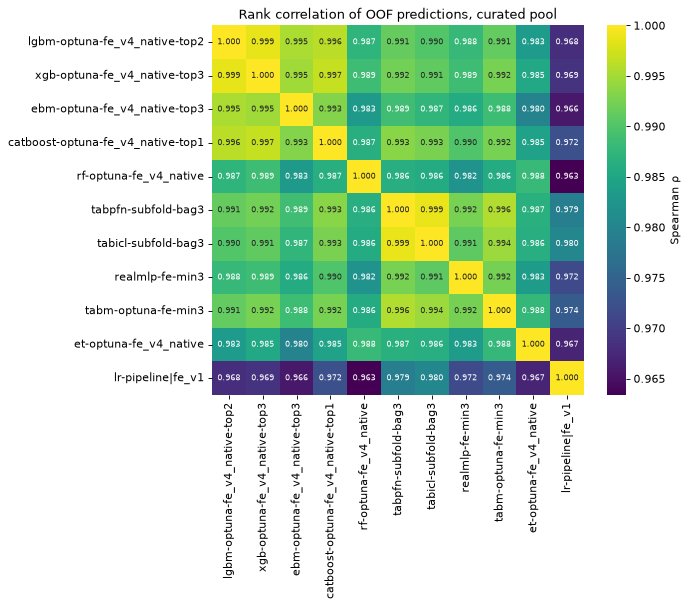

In [3]:
curated = bl.curate_pool(meta)
full = list(oof.columns)
cm = meta.set_index('label').loc[curated, ['family', 'engine', 'oof_roc_auc', 'mean_rho']]
print(f'Curated pool: {len(curated)} of {len(full)} runs\n')
print(cm.to_string(formatters={'oof_roc_auc': '{:.5f}'.format, 'mean_rho': '{:.3f}'.format}))

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(spearman.loc[curated, curated], annot=True, fmt='.3f', cmap='viridis',
            annot_kws={'size': 7}, cbar_kws={'label': 'Spearman ρ'}, ax=ax)
ax.set_title('Rank correlation of OOF predictions, curated pool')
plt.show()

## 4. Compare combiners on the OOF predictions

Every combiner is scored on the same yardstick: ROC-AUC of its OOF predictions.
Combiners that learn weights (hill climbing, stacking) are themselves
cross-validated over the **same five folds**, so their OOF scores are leakage-free
too.

* **Equal-weight mean** of all runs and of the curated pool.
* **Rank mean** — averages ranks instead of probabilities; indifferent to one model
  being over-confident.
* **Strength-weighted mean** — weights ∝ softmax(AUC / T); small T concentrates
  weight on the strongest members.
* **Hill climbing** (Caruana ensemble selection) — greedily adds, with
  replacement, whichever member most improves the ensemble's AUC; bagged over 25
  random half-pools to stabilise the weights.
* **Logistic-regression stack** on the standardised log-odds of each member, with
  L2 strength C swept on both the curated and the full pool.
* **LightGBM stack** — a non-linear meta-learner, to test whether interactions
  between models help.

In [4]:
def auc(p):
    return roc_auc_score(y, p)

best_single = meta['oof_roc_auc'].max()
results = {
    'equal mean, all runs': auc(bl.equal_mean(oof, test, full)[0]),
    'equal mean, curated':  auc(bl.equal_mean(oof, test, curated)[0]),
    'rank mean, curated':   auc(bl.rank_mean(oof, test, curated)[0]),
}
for T in (0.005, 0.001):
    results[f'softmax(AUC/T), T={T}'] = auc(bl.softmax_auc(oof, test, curated, y, T)[0])

hc_oof, _, hc_w = bl.hill_climb(oof, test, curated, y)
results['hill climb, curated'] = auc(hc_oof)

for pool_name, cols in (('curated', curated), ('all runs', full)):
    for C in (0.01, 0.1, 1.0):
        results[f'logistic stack, {pool_name}, C={C:g}'] = auc(
            bl.logit_stack(oof, test, cols, y, folds, C)[0])

# LightGBM stack with the hyperparameters of the logged headline LightGBM stack
# (found by a 50-trial Optuna search when the blends were fixed).
lgbm_stack_run = load_runs().query("tag == 'stack-lgbm-optuna-curated-v2'").iloc[0]
lgbm_params = json.loads((RUNS_DIR / lgbm_stack_run['run_id'] / 'params.json')
                         .read_text())['lgbm_params']
results['LightGBM stack, curated'] = auc(
    bl.lgbm_stack(oof, test, curated, y, folds, params=lgbm_params)[0])

table = (pd.Series(results, name='oof_roc_auc').to_frame()
           .assign(vs_best_single=lambda d: d['oof_roc_auc'] - best_single)
           .sort_values('oof_roc_auc', ascending=False))
print(f'best single model: {best_single:.6f}\n')
print(table.to_string(formatters={'oof_roc_auc': '{:.6f}'.format,
                                  'vs_best_single': '{:+.6f}'.format}))

best single model: 0.916810

                                 oof_roc_auc vs_best_single
logistic stack, all runs, C=1       0.917243      +0.000434
logistic stack, all runs, C=0.1     0.917233      +0.000423
logistic stack, all runs, C=0.01    0.917229      +0.000419
logistic stack, curated, C=1        0.917185      +0.000376
logistic stack, curated, C=0.1      0.917181      +0.000371
logistic stack, curated, C=0.01     0.917172      +0.000363
hill climb, curated                 0.917162      +0.000353
softmax(AUC/T), T=0.001             0.917095      +0.000286
LightGBM stack, curated             0.917082      +0.000272
equal mean, all runs                0.916596      -0.000213
softmax(AUC/T), T=0.005             0.916518      -0.000292
equal mean, curated                 0.916014      -0.000795
rank mean, curated                  0.915963      -0.000847


In [5]:
w = pd.Series(hc_w, index=curated)
print('Hill-climbing weights (selection frequency):')
print(w[w > 0].sort_values(ascending=False).to_string(float_format='{:.3f}'.format))

Hill-climbing weights (selection frequency):
ebm-optuna-fe_v4_native-top3        0.357
xgb-optuna-fe_v4_native-top3        0.251
lgbm-optuna-fe_v4_native-top2       0.221
catboost-optuna-fe_v4_native-top1   0.130
rf-optuna-fe_v4_native              0.027
tabicl-subfold-bag3                 0.013


Three points stand out.

* **Equal weighting is a trap here.** Averaging the curated pool with equal weights
  scores *below* the best single model (−0.0008): the weaker members get the same
  vote as the best ones. Rank averaging is no better.
* **What works concentrates weight on the strong models while keeping a little
  diversity.** Every learned combiner beats the best single model, by +0.0003 to
  +0.0004. Hill climbing puts 96% of its weight on the four boosted-tree engines and
  gives the neural nets and foundation models essentially none; the logistic stack
  keeps all 11 with small positive or negative coefficients.
* **The gains are small against the noise.** +0.0004 is less than half of one fold's
  standard deviation. The differences *between* the combiners are smaller still
  (about 0.0001 across the logistic stacks), so their OOF ranking says little about
  how they will rank on unseen data.

## 5. What held-out data said: pre-registration vs. picking the OOF winner

The gains above are a few ten-thousandths of AUC, while the best single model's
AUC varies by about 0.0009 from one fold to the next. At that scale, **choosing
the combiner with the highest OOF score is itself a source of optimism**: out of
many noisy estimates, the maximum is biased upwards.

So six blends were fixed *before* any leaderboard score was seen — three
pre-registered robust defaults (the rank mean, a moderate-C logistic stack on the
curated pool, and hill climbing), plus the OOF sweep's winner (a strongly
regularised logistic stack over every aligned run), a strength-weighted mean and
the LightGBM stack — logged as ordinary ledger rows, and submitted. The competition
has since closed, so the private leaderboard gives held-out truth for each:

In [6]:
ledger = load_runs()
headline = (ledger[(ledger['data_version'] == 'blend_v1') & ledger['tag'].str.endswith('-v2')]
            .set_index('tag')[['oof_roc_auc', 'fold_roc_auc_std', 'lb_public', 'lb_private']]
            .sort_values('oof_roc_auc', ascending=False))
single = ledger.set_index('tag').loc[['lgbm-optuna-fe_v4_native-top2'],
                                     ['oof_roc_auc', 'fold_roc_auc_std', 'lb_public', 'lb_private']]
view = pd.concat([headline, single.rename(index=lambda t: f'{t} (best single)')])
view['oof_rank'] = view['oof_roc_auc'].rank(ascending=False).astype(int)
view['private_rank'] = view['lb_private'].rank(ascending=False, method='min').astype(int)
view.style.format({'oof_roc_auc': '{:.5f}', 'fold_roc_auc_std': '{:.5f}',
                   'lb_public': '{:.5f}', 'lb_private': '{:.5f}'})

,oof_roc_auc,fold_roc_auc_std,lb_public,lb_private,oof_rank,private_rank
tag,,,,,,
stack-logit-lr-best-v2,0.91729,0.00097,0.91438,0.91564,1,5
stack-logit-lr-curated-c1-v2,0.91719,0.00095,0.91456,0.91582,2,1
blend-hillclimb-curated-v2,0.91716,0.00094,0.91450,0.91576,3,2
blend-softmax-curated-v2,0.91710,0.00094,0.91440,0.91567,4,4
stack-lgbm-optuna-curated-v2,0.91708,0.00095,0.91452,0.91570,5,3
blend-rank-mean-curated-v2,0.91596,0.00094,0.91310,0.91441,7,7
lgbm-optuna-fe_v4_native-top2 (best single),0.91681,0.00093,0.91429,0.91558,6,6


* **The OOF favourite did not win.** The full-pool stack had the highest OOF score
  (0.91729) and finished fifth of the six on the private leaderboard (0.91564). The
  pre-registered curated logistic stack (OOF 0.91719) was best on *both* public and
  private leaderboards (0.91456 / 0.91582). The OOF edge of the argmax was noise —
  exactly the selection bias that pre-registration guards against. (The full-pool
  stack also included the level-2 stacking runs, which generalise worse; see
  `04_Results.ipynb`.)
* **Blending helped, modestly.** The winning stack beat the best single model by
  +0.00024 on the private leaderboard, consistent with the OOF gain and with
  blending as variance reduction rather than new signal.
* **OOF was a reliable guide to *whether* blending helps, not to which of several
  near-equal blends is best.** The blends' OOF-to-private offsets (0.0014–0.0017)
  are close to the base models' 0.0013, but their spread is as large as the
  differences between them.

### Reproducing the winning blend from its record

The ledger row for a blend stores its members and coefficients in `params.json`.
Re-fitting the logistic stack from that member list must reproduce the logged OOF
score exactly.

In [7]:
rec = ledger.set_index('tag').loc['stack-logit-lr-curated-c1-v2']
spec = json.loads((RUNS_DIR / rec['run_id'] / 'params.json').read_text())
oof_p, _, coef = bl.logit_stack(oof, test, spec['members'], y, folds, spec['C'])
print(f"members: {len(spec['members'])}   C={spec['C']}")
print(f"OOF ROC-AUC  logged {rec['oof_roc_auc']:.9f}   refit {auc(oof_p):.9f}")
assert abs(auc(oof_p) - rec['oof_roc_auc']) < 1e-9
print(pd.Series(coef, index=spec['members'], name='coefficient')
      .sort_values(ascending=False).to_string(float_format='{:+.3f}'.format))

members: 11   C=1.0
OOF ROC-AUC  logged 0.917185089   refit 0.917185089


ebm-optuna-fe_v4_native-top3        +0.936
lgbm-optuna-fe_v4_native-top2       +0.677
catboost-optuna-fe_v4_native-top1   +0.641
xgb-optuna-fe_v4_native-top3        +0.635
rf-optuna-fe_v4_native              +0.162
tabicl-subfold-bag3                 +0.034
lr-pipeline|fe_v1                   -0.005
tabpfn-subfold-bag3                 -0.035
et-optuna-fe_v4_native              -0.073
realmlp-fe-min3                     -0.093
tabm-optuna-fe-min3                 -0.102


The four boosted-tree engines carry the stack; the random forest adds a little; the
six neural, in-context and linear models enter with coefficients near zero, some
negative. On log-odds features a small negative weight on a model that is highly
correlated with the rest acts as a correction term rather than a vote against it.
The diversity those models offer is real (section 2) but, at this signal level, small.